# 06 — Explicabilité : SHAP + LIME

**Objectif :** Expliquer les décisions de tous les modèles (LR, RF, AutoEncoder)
en combinant SHAP (global + local) et LIME (local).

**Structure :**
1. Setup & chargement
2. Installation et vérification SHAP/LIME
3. SHAP pour Random Forest (TreeExplainer — rapide)
4. SHAP pour Logistic Regression (LinearExplainer)
5. SHAP pour AutoEncoder (DeepExplainer)
6. Comparaison globale SHAP tous modèles
7. LIME — explication locale transaction frauduleuse
8. SHAP vs LIME côte-à-côte
9. Intégration LLM — prompt enrichi SHAP+LIME
10. Sauvegarde

**Installation :**
```bash
pip install shap lime
```

In [14]:
from pathlib import Path
import sys, json, time, warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

print(f'shap  : {shap.__version__}')

# ── Chemins
project_root  = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

PROCESSED_DIR = project_root / 'data'    / 'processed'
MODELS_DIR    = project_root / 'outputs' / 'models'
REPORTS_DIR   = project_root / 'outputs' / 'reports'
FIGURES_DIR   = project_root / 'outputs' / 'figures'

POS  = '#E74C3C'
NEG  = '#2980B9'
PURP = '#8E44AD'

FEAT_LABELS = {
    'step':'Etape temporelle','hour':'Heure','day':'Jour','week':'Semaine',
    'high_risk_hour':'Heure a risque','is_transfer_or_cashout':'TRANSFER/CASH_OUT',
    'balance_diff_orig':'Diff. solde emetteur','dest_zero_balance':'Dest. solde nul',
    'type_CASH_IN':'CASH_IN','type_CASH_OUT':'CASH_OUT','type_DEBIT':'DEBIT',
    'type_PAYMENT':'PAYMENT','type_TRANSFER':'TRANSFER','log_amount':'Montant (log)',
}
CAT_FEATS = ['high_risk_hour','is_transfer_or_cashout','dest_zero_balance',
             'type_CASH_IN','type_CASH_OUT','type_DEBIT','type_PAYMENT','type_TRANSFER']

print('Setup OK')

shap  : 0.51.0
Setup OK


## 1 — Vérification des dépendances

In [15]:
import importlib

deps = {'shap': 'pip install shap', 'lime': 'pip install lime'}
for pkg, install_cmd in deps.items():
    try:
        importlib.import_module(pkg)
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        print(f'  ✅ {pkg} {ver}')
    except ImportError:
        print(f'  ❌ {pkg} manquant → {install_cmd}')
        raise ImportError(f'{pkg} requis. Lance : {install_cmd}')

import shap
from lime.lime_tabular import LimeTabularExplainer
print('\n✅ SHAP et LIME disponibles.')

  ✅ shap 0.51.0
  ✅ lime unknown

✅ SHAP et LIME disponibles.


## 2 — Chargement des données et modèles

In [16]:
# ── Features
with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
    meta = json.load(f)
FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')
TARGET       = meta.get('target', 'isFraud')
print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')

Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']


In [17]:
# ── Chargement des splits ─────────────────────────────────────────────────────
def load_split(prefix):
    csv_X = PROCESSED_DIR / f'X_{prefix}.csv'
    csv_y = PROCESSED_DIR / f'y_{prefix}.csv'
    if csv_X.exists():
        X = pd.read_csv(csv_X)[FEATURE_COLS].astype(float)
        y = pd.read_csv(csv_y).iloc[:,0].astype(int)
    else:
        X = pd.DataFrame(np.load(PROCESSED_DIR/f'X_{prefix}.npy',allow_pickle=True).astype(float), columns=FEATURE_COLS)
        y = pd.Series(np.load(PROCESSED_DIR/f'y_{prefix}.npy',allow_pickle=True).astype(int), name=TARGET)
    return X, y

X_train, y_train = load_split('train')
X_test,  y_test  = load_split('test')

X_train_arr = X_train.values.astype(np.float32)
X_test_arr  = X_test.values.astype(np.float32)

print(f'X_train : {X_train.shape}  fraudes={int(y_train.sum())}')
print(f'X_test  : {X_test.shape}   fraudes={int(y_test.sum())}')

X_train : (139999, 14)  fraudes=181
X_test  : (30001, 14)   fraudes=39


In [18]:
# ── Imports sklearn (nécessaires pour pickle) ─────────────────────────────────
import joblib
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from src.models.autoencoder import FraudAutoEncoder

def load_model(path):
    try:    obj = joblib.load(path)
    except: obj = pickle.load(open(path,'rb'))
    if isinstance(obj, dict):
        return obj.get('model', list(obj.values())[0])
    return obj

lr_balanced = load_model(MODELS_DIR / 'lr_balanced.pkl')
lr_smote    = load_model(MODELS_DIR / 'lr_smote.pkl')
rf_balanced = load_model(MODELS_DIR / 'rf_balanced.pkl')
rf_smote    = load_model(MODELS_DIR / 'rf_smote.pkl')
ae          = FraudAutoEncoder.load(MODELS_DIR / 'autoencoder')
ae_scores_test = np.load(MODELS_DIR / 'ae_scores_test.npy')

print(f'rf_smote type  : {type(rf_smote).__name__}')
print(f'lr_smote type  : {type(lr_smote).__name__}')
print(f'AE seuil       : {ae.threshold:.4f}')

# ── Extraire les estimateurs sklearn BRUTS depuis les wrappers ──────────────
# FraudRandomForest et FraudLogisticRegression wrappent le modèle sklearn.
# SHAP a besoin du modèle sklearn brut. On cherche l'attribut dans l'ordre.
def get_raw(wrapper):
    """
    Extrait l'estimateur sklearn brut d'un wrapper custom.
    Si l'objet est deja un estimateur sklearn reconnu (RF, LR...), le retourne tel quel.
    Ne pas utiliser getattr() sur des classes sklearn qui ont des attributs 'estimators_'
    qui sont des listes d'arbres individuels.
    """
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    from sklearn.linear_model import LogisticRegression

    # Deja un estimateur sklearn pur -> retourner directement
    if isinstance(wrapper, (RandomForestClassifier, RandomForestRegressor,
                            LogisticRegression)):
        return wrapper

    # Wrapper custom -> chercher l'estimateur interne
    # IMPORTANT : exclure 'model' pour les RF sklearn (rf.model = base estimator = DecisionTree)
    for attr in ('estimator_', 'best_estimator_', 'classifier_', 'clf_', '_clf',
                 'regressor_', '_model', 'base_model'):
        candidate = getattr(wrapper, attr, None)
        if candidate is not None and hasattr(candidate, 'fit'):
            return candidate

    # Fallback : chercher 'model' seulement si ce n'est PAS un RF/LR sklearn
    candidate = getattr(wrapper, 'model', None)
    if candidate is not None and hasattr(candidate, 'fit'):
        cname = type(candidate).__name__
        if cname not in ('DecisionTreeClassifier','DecisionTreeRegressor'):
            return candidate

    return wrapper  # retourner tel quel

rf_smote_raw    = get_raw(rf_smote)
rf_balanced_raw = get_raw(rf_balanced)
lr_smote_raw    = get_raw(lr_smote)
lr_balanced_raw = get_raw(lr_balanced)

print(f'rf_smote_raw   : {type(rf_smote_raw).__name__}')
print(f'lr_smote_raw   : {type(lr_smote_raw).__name__}')

# ── predict_proba wrappers compatibles LIME/SHAP (retournent toujours 2D) ──
def proba_2d(wrapper):
    """Retourne une fonction X -> array (N,2) compatible sklearn."""
    def fn(X):
        X = np.array(X, dtype=np.float32)
        p = wrapper.predict_proba(X)             # shape (N,) ou (N,2)
        if p.ndim == 1:                           # wrapper retourne 1D
            return np.column_stack([1-p, p])
        return p
    return fn

rf_smote_proba_fn    = proba_2d(rf_smote)
rf_balanced_proba_fn = proba_2d(rf_balanced)
lr_smote_proba_fn    = proba_2d(lr_smote)

# Test
p = rf_smote_proba_fn(X_test_arr[:3])
print(f'\nTest proba_2d RF_smote : shape={p.shape}  valeurs={p[:2]}')

rf_smote type  : RandomForestClassifier
lr_smote type  : LogisticRegression
AE seuil       : 1.7530
rf_smote_raw   : RandomForestClassifier
lr_smote_raw   : LogisticRegression

Test proba_2d RF_smote : shape=(3, 2)  valeurs=[[0.99386986 0.00613014]
 [0.98567729 0.01432271]]


In [19]:
## ── Seuils optimaux ───────────────────────────────────────────────────────────
#with open(MODELS_DIR / 'optimal_thresholds.json') as f:
 #   thresholds = json.load(f)

#print('Seuils optimaux :')
#for name, t in thresholds.items():
#    print(f'  {name:<15s} : {t:.4f}')
#print(f'  AutoEncoder    : {ae.threshold:.4f}')

## 3 — SHAP : Random Forest (TreeExplainer)

In [20]:
# Background : 300 transactions normales
normal_idx = np.where(y_train.values == 0)[0]
np.random.seed(42)
bg_idx = np.random.choice(normal_idx, size=min(300, len(normal_idx)), replace=False)
X_bg   = X_train_arr[bg_idx]
print(f'Background : {X_bg.shape}')

# ── TreeExplainer RF_smote ──────────────────────────────────────────────────
# rf_smote est deja un RandomForestClassifier sklearn -> passer directement
# (get_raw retourne rf_smote lui-meme, pas un sous-arbre)
print(f'rf_smote final type pour SHAP : {type(rf_smote_raw).__name__}')
assert 'Forest' in type(rf_smote_raw).__name__ or 'Boosting' in type(rf_smote_raw).__name__, \
    f'ERREUR : rf_smote_raw doit etre un RandomForest, pas {type(rf_smote_raw).__name__}'

print('TreeExplainer RF_smote...', end=' ')
t0 = time.time()
explainer_rf = shap.TreeExplainer(rf_smote_raw)

# Calcul sur 500 lignes
shap_rf_raw = explainer_rf.shap_values(X_test_arr[:500], check_additivity=False)

# shap_values RF binaire -> liste [class0, class1] -> prendre class1
if isinstance(shap_rf_raw, list):
    shap_rf = np.array(shap_rf_raw[1])
elif shap_rf_raw.ndim == 3:
    shap_rf = shap_rf_raw[:,:,1]
else:
    shap_rf = shap_rf_raw

print(f'OK ({time.time()-t0:.1f}s)  shape={shap_rf.shape}')
print(f'|SHAP| moyen = {np.abs(shap_rf).mean():.4f}')
mean_abs = np.abs(shap_rf).mean(axis=0)
top_feat = FEATURE_COLS[np.argmax(mean_abs)]
print(f'Feature #1 : {top_feat} ({mean_abs.max():.4f})')


Background : (300, 14)
rf_smote final type pour SHAP : RandomForestClassifier
TreeExplainer RF_smote... OK (10.0s)  shape=(500, 14)
|SHAP| moyen = 0.0115
Feature #1 : balance_diff_orig (0.0440)


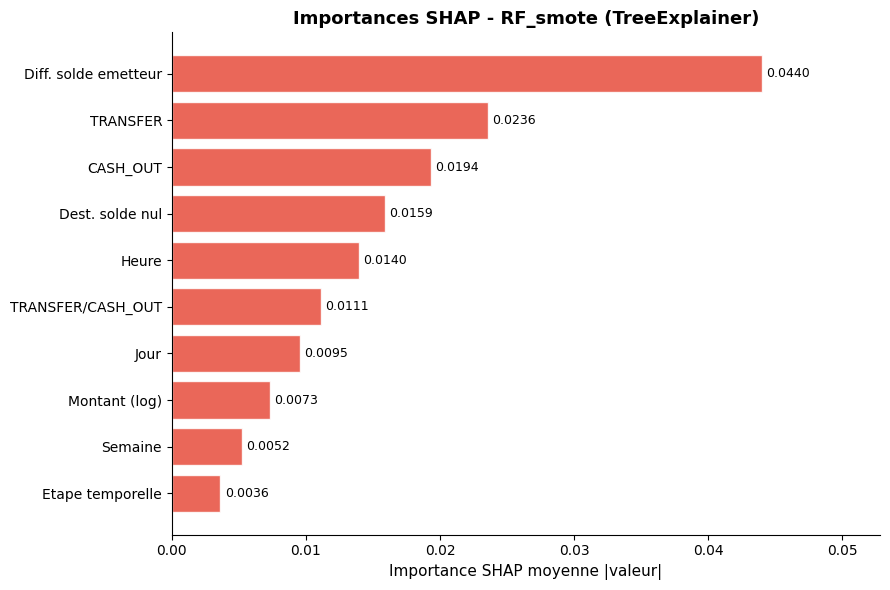

Figure 26 sauvegardee


In [21]:
# ── Figure 26 : Bar importances SHAP RF_smote ─────────────────────────────────
mean_abs_rf = np.abs(shap_rf).mean(axis=0)
order_rf    = np.argsort(mean_abs_rf)[::-1][:10]
labels_rf   = [FEAT_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in order_rf]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels_rf[::-1], mean_abs_rf[order_rf][::-1], color=POS, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.set_xlabel('Importance SHAP moyenne |valeur|', fontsize=11)
ax.set_title('Importances SHAP - RF_smote (TreeExplainer)', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, mean_abs_rf[order_rf].max() * 1.20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '26_shap_rf_smote_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 26 sauvegardee')

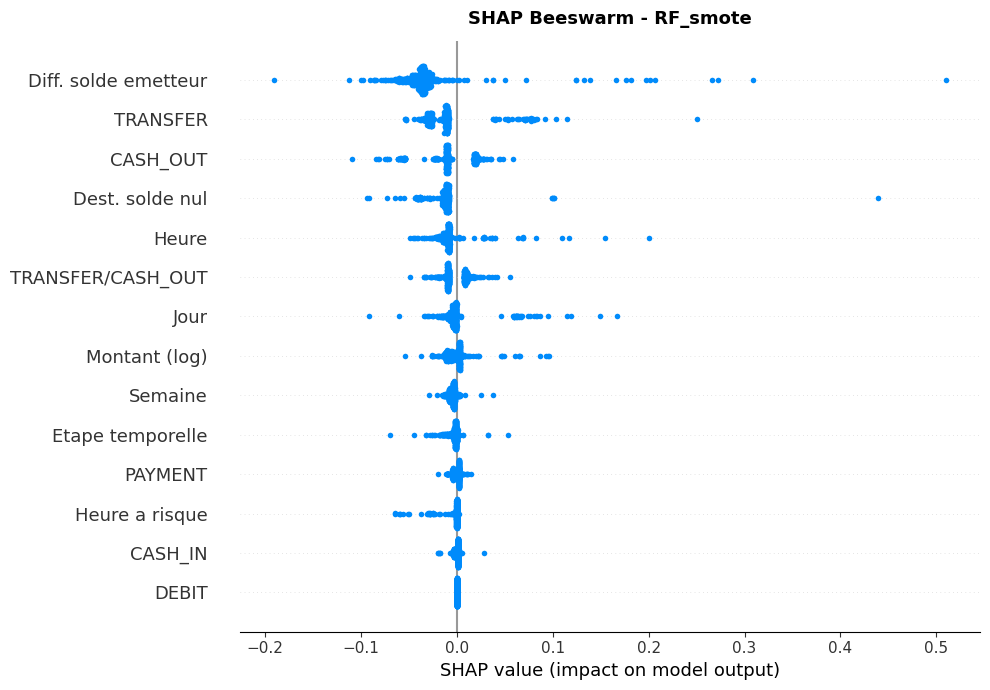

Figure 27 sauvegardee


In [22]:
# ── Figure 27 : Beeswarm SHAP RF_smote ───────────────────────────────────────
feat_labels_list = [FEAT_LABELS.get(f, f) for f in FEATURE_COLS]
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_rf, feature_names=feat_labels_list, max_display=14, show=False, plot_size=None)
plt.title('SHAP Beeswarm - RF_smote', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '27_shap_rf_smote_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 27 sauvegardee')

## 4 — SHAP : Logistic Regression (LinearExplainer)

LinearExplainer LR_smote... OK (0.1s)  shape=(500, 14)
|SHAP| moyen LR = 0.5975


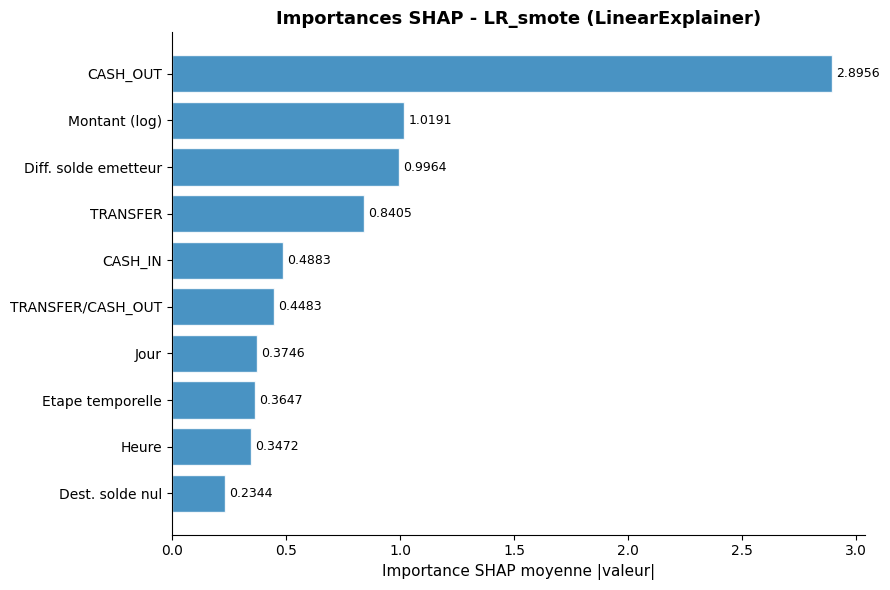

Figure 28 sauvegardee


In [23]:
print('LinearExplainer LR_smote...', end=' ')
t0 = time.time()
explainer_lr = shap.LinearExplainer(lr_smote_raw, X_bg)
shap_lr      = explainer_lr.shap_values(X_test_arr[:500])

# LinearExplainer retourne directement (N, 14) — pas de liste
if isinstance(shap_lr, list): shap_lr = shap_lr[1] if len(shap_lr)>1 else shap_lr[0]
print(f'OK ({time.time()-t0:.1f}s)  shape={shap_lr.shape}')
print(f'|SHAP| moyen LR = {np.abs(shap_lr).mean():.4f}')

# Figure 28
mean_abs_lr = np.abs(shap_lr).mean(axis=0)
order_lr    = np.argsort(mean_abs_lr)[::-1][:10]
labels_lr   = [FEAT_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in order_lr]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels_lr[::-1], mean_abs_lr[order_lr][::-1], color=NEG, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.set_xlabel('Importance SHAP moyenne |valeur|', fontsize=11)
ax.set_title('Importances SHAP - LR_smote (LinearExplainer)', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '28_shap_lr_smote_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 28 sauvegardee')

## 5 — SHAP : AutoEncoder (DeepExplainer)

DeepExplainer AutoEncoder... OK (71.5s)  shape=(200, 14)
|SHAP| moyen AE = 0.0138


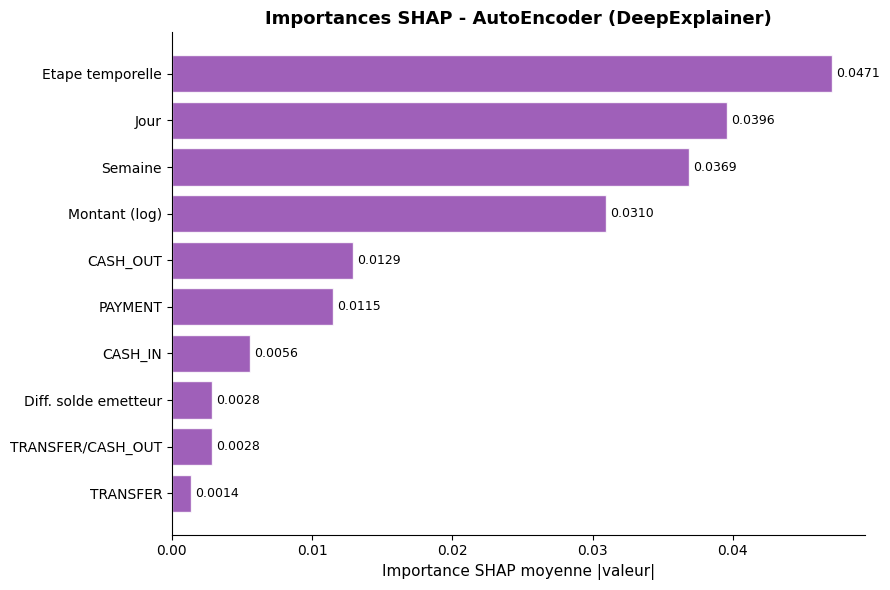

Figure 29 sauvegardee


In [24]:
print('DeepExplainer AutoEncoder...', end=' ')
t0 = time.time()
import torch

ae.model.eval()
ae_device = next(ae.model.parameters()).device
bg_ae = torch.from_numpy(X_bg[:100].astype(np.float32)).to(ae_device)
X_test_ae = torch.from_numpy(X_test_arr[:200].astype(np.float32)).to(ae_device)
explainer_ae = shap.DeepExplainer(ae.model, bg_ae)
shap_ae_raw  = explainer_ae.shap_values(X_test_ae)

# DeepExplainer retourne liste d'arrays (un par output)
# AE a 14 outputs (reconstruction) -> moyenne sur les outputs
if isinstance(shap_ae_raw, list):
    shap_ae = np.stack(shap_ae_raw, axis=-1).mean(axis=-1)  # (N, 14)
elif shap_ae_raw.ndim == 3:
    shap_ae = shap_ae_raw.mean(axis=2)
else:
    shap_ae = shap_ae_raw

if hasattr(shap_ae, 'detach'):
    shap_ae = shap_ae.detach().cpu().numpy()

print(f'OK ({time.time()-t0:.1f}s)  shape={shap_ae.shape}')
print(f'|SHAP| moyen AE = {np.abs(shap_ae).mean():.4f}')

# Figure 29
mean_abs_ae = np.abs(shap_ae).mean(axis=0)
order_ae    = np.argsort(mean_abs_ae)[::-1][:10]
labels_ae   = [FEAT_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in order_ae]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels_ae[::-1], mean_abs_ae[order_ae][::-1], color=PURP, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.set_xlabel('Importance SHAP moyenne |valeur|', fontsize=11)
ax.set_title('Importances SHAP - AutoEncoder (DeepExplainer)', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '29_shap_ae_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 29 sauvegardee')

## 6 — Comparaison SHAP tous modèles (Figure 30)

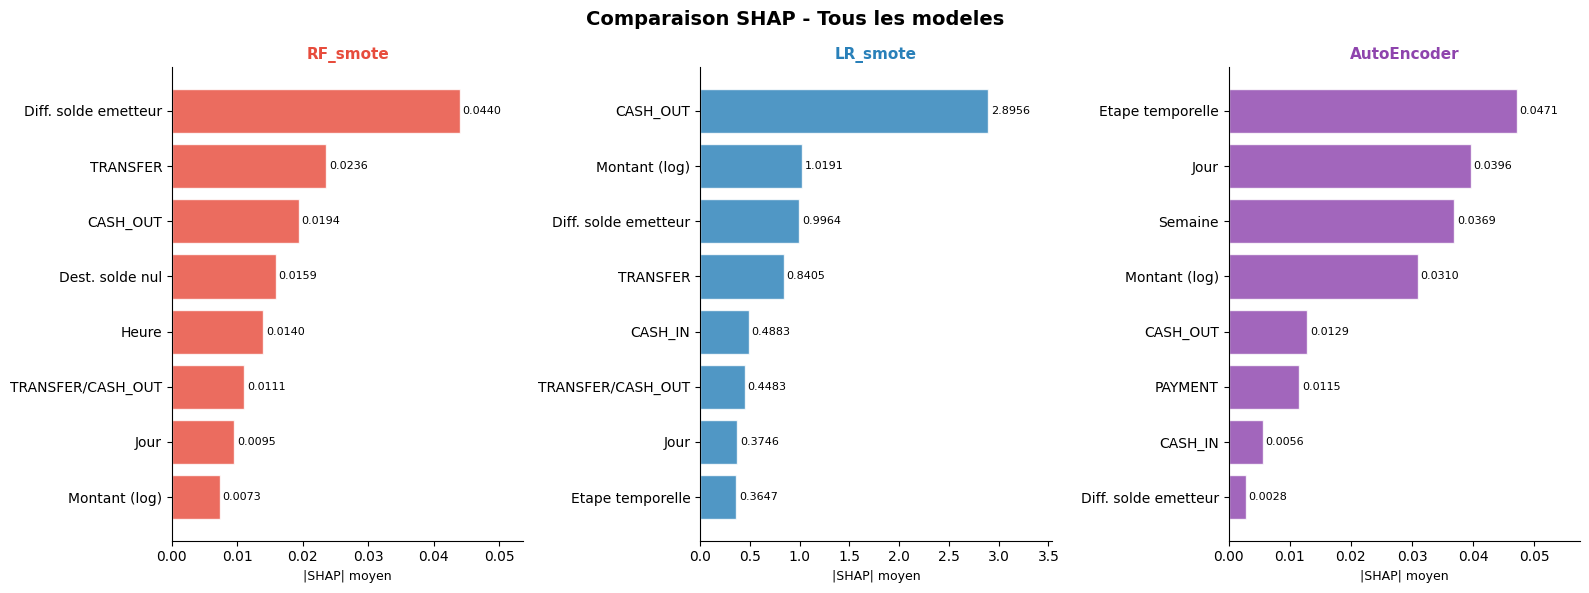

Figure 30 sauvegardee

=== Top-5 SHAP par modele ===

RF_smote:
  balance_diff_orig              0.0440
  type_TRANSFER                  0.0236
  type_CASH_OUT                  0.0194
  dest_zero_balance              0.0159
  hour                           0.0140

LR_smote:
  type_CASH_OUT                  2.8956
  log_amount                     1.0191
  balance_diff_orig              0.9964
  type_TRANSFER                  0.8405
  type_CASH_IN                   0.4883

AutoEncoder:
  step                           0.0471
  day                            0.0396
  week                           0.0369
  log_amount                     0.0310
  type_CASH_OUT                  0.0129


In [25]:
shap_dict = {
    'RF_smote'   : (shap_rf,  POS,  mean_abs_rf),
    'LR_smote'   : (shap_lr,  NEG,  mean_abs_lr),
    'AutoEncoder': (shap_ae,  PURP, mean_abs_ae),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Comparaison SHAP - Tous les modeles', fontsize=14, fontweight='bold')

for ax, (mname, (_, color, mabs)) in zip(axes, shap_dict.items()):
    top8   = np.argsort(mabs)[::-1][:8]
    lbls   = [FEAT_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in top8][::-1]
    vals   = mabs[top8][::-1]
    bars   = ax.barh(lbls, vals, color=color, alpha=0.82, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2)
    ax.set_title(mname, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('|SHAP| moyen', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlim(0, max(vals.max()*1.22, 0.0001))

plt.tight_layout()
plt.savefig(FIGURES_DIR / '30_shap_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 30 sauvegardee')

print('\n=== Top-5 SHAP par modele ===')
for mname, (_, _, mabs) in shap_dict.items():
    top5 = np.argsort(mabs)[::-1][:5]
    print(f'\n{mname}:')
    for i in top5:
        print(f'  {FEATURE_COLS[i]:<30s} {mabs[i]:.4f}')

## 7 — Transaction à expliquer (TP avec score AE le plus élevé)

In [26]:
with open(MODELS_DIR / 'optimal_thresholds.json') as f:
    thresholds = json.load(f)

y_test_arr = y_test.values
tp_mask    = (ae_scores_test >= ae.threshold) & (y_test_arr == 1)
tp_idx     = np.where(tp_mask)[0]

if len(tp_idx) == 0:
    fraud_idx   = np.where(y_test_arr == 1)[0]
    tx_idx      = fraud_idx[np.argmax(ae_scores_test[fraud_idx])]
else:
    tx_idx = tp_idx[np.argmax(ae_scores_test[tp_idx])]

tx          = X_test_arr[tx_idx]          # shape (14,)
ae_score_tx = float(ae_scores_test[tx_idx])
true_label  = int(y_test_arr[tx_idx])
rf_prob_tx  = float(rf_smote_proba_fn(tx.reshape(1,-1))[0][1])

print(f'Transaction idx={tx_idx} | label={true_label} | AE={ae_score_tx:.2f} | RF={rf_prob_tx:.4f}')
print('Features :')
for f, v in zip(FEATURE_COLS, tx):
    print(f'  {f:<32s} = {v:.4f}')

Transaction idx=29340 | label=1 | AE=313.65 | RF=0.9880
Features :
  step                             = 3.4143
  hour                             = -1.2305
  day                              = 3.4564
  week                             = 3.4727
  high_risk_hour                   = 0.0000
  is_transfer_or_cashout           = 1.0000
  balance_diff_orig                = 66.0686
  dest_zero_balance                = 1.0000
  type_CASH_IN                     = 0.0000
  type_CASH_OUT                    = 0.0000
  type_DEBIT                       = 0.0000
  type_PAYMENT                     = 0.0000
  type_TRANSFER                    = 1.0000
  log_amount                       = 2.9061


## 8 — SHAP waterfall sur la transaction (Figure 33)

SHAP valeurs pour cette transaction :
       feature_label  shap_value  feature_value
Diff. solde emetteur    0.320542      66.068550
     Dest. solde nul    0.234996       1.000000
            TRANSFER    0.114318       1.000000
       Montant (log)    0.097422       2.906082
                Jour    0.073623       3.456422
            CASH_OUT   -0.051924       0.000000
   TRANSFER/CASH_OUT    0.048036       1.000000
    Etape temporelle    0.038603       3.414292
             CASH_IN    0.015405       0.000000
               Heure   -0.013284      -1.230454


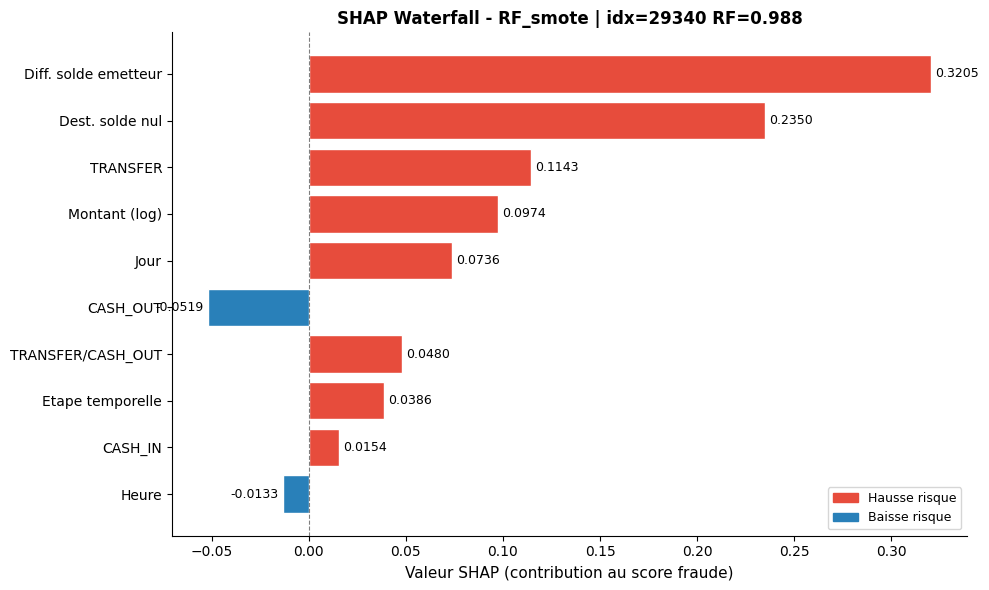

Figure 33 sauvegardee


In [27]:
# Valeurs SHAP pour cette transaction spécifique
tx_2d      = tx.reshape(1,-1).astype(np.float32)
sv_raw     = explainer_rf.shap_values(tx_2d, check_additivity=False)
sv_tx      = sv_raw[1][0] if isinstance(sv_raw, list) else sv_raw[0]
if sv_tx.ndim == 2: sv_tx = sv_tx[:,1]

shap_df = pd.DataFrame({
    'feature'      : FEATURE_COLS,
    'feature_label': [FEAT_LABELS.get(f,f) for f in FEATURE_COLS],
    'shap_value'   : sv_tx,
    'feature_value': tx,
}).sort_values('shap_value', key=abs, ascending=False)

print('SHAP valeurs pour cette transaction :')
print(shap_df[['feature_label','shap_value','feature_value']].head(10).to_string(index=False))

# Figure 33
top10  = shap_df.head(10)
colors = [POS if v > 0 else NEG for v in top10['shap_value']]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['feature_label'][::-1], top10['shap_value'][::-1], color=colors[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Valeur SHAP (contribution au score fraude)', fontsize=11)
ax.set_title(f'SHAP Waterfall - RF_smote | idx={tx_idx} RF={rf_prob_tx:.3f}', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
p1 = mpatches.Patch(color=POS, label='Hausse risque')
p2 = mpatches.Patch(color=NEG, label='Baisse risque')
ax.legend(handles=[p1,p2], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '33_shap_waterfall_single.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 33 sauvegardee')

## 9 — LIME RF_smote (Figure 31)

LIMEExplainer cree
LIME RF_smote... OK (0.3s)
Prediction locale RF : 0.7172  (label utilise=1)
Poids LIME RF_smote :
  +0.1722  balance_diff_orig > 0.20
  +0.1437  dest_zero_balance=1
  +0.1068  type_TRANSFER=1
  +0.1001  day > 0.76
  +0.0895  hour <= -0.77
  -0.0884  type_CASH_OUT=0
  +0.0621  is_transfer_or_cashout=1
  +0.0476  week > 1.15
  +0.0361  high_risk_hour=0
  +0.0361  type_PAYMENT=0


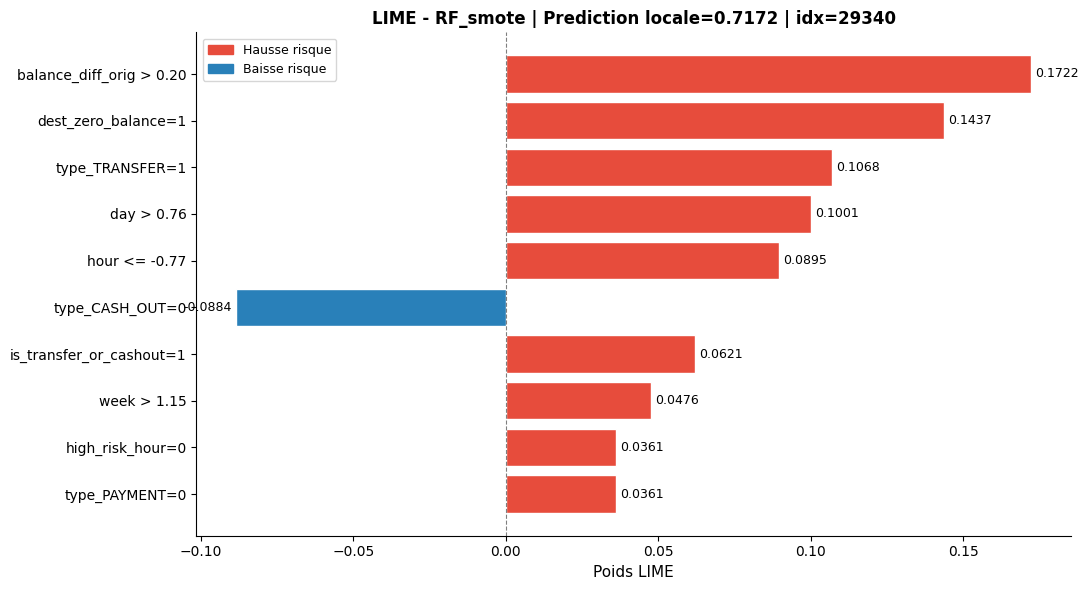

Figure 31 sauvegardee


In [28]:
cat_idx = [i for i, f in enumerate(FEATURE_COLS) if f in CAT_FEATS]

lime_explainer = LimeTabularExplainer(
    training_data         = X_train_arr,
    feature_names         = FEATURE_COLS,
    categorical_features  = cat_idx,
    mode                  = 'classification',
    random_state          = 42,
    discretize_continuous = True,
)
print('LIMEExplainer cree')

# ── explain_instance avec predict_fn 2D ──────────────────────────────────────
print('LIME RF_smote...', end=' ')
t0 = time.time()
exp_rf = lime_explainer.explain_instance(
    data_row    = tx,
    predict_fn  = rf_smote_proba_fn,   # retourne (N,2) -- obligatoire pour LIME classification
    num_features = 10,
    num_samples  = 1000,
)
print(f'OK ({time.time()-t0:.1f}s)')

# ── Extraction robuste local_pred ────────────────────────────────────────────
# LIME peut avoir local_pred de taille 1 ou 2 selon les labels presents.
# On prend le dernier element (correspond toujours a la classe positive).
lp_rf      = exp_rf.local_pred
local_pred_rf = float(lp_rf[-1]) if hasattr(lp_rf,'__len__') else float(lp_rf)

available_labels = sorted(exp_rf.as_map().keys())
use_label = available_labels[-1]   # dernier = classe 1 si present, sinon classe 0

pairs_rf  = exp_rf.as_list(label=use_label)
rules_rf  = [p[0] for p in pairs_rf]
weights_rf= [p[1] for p in pairs_rf]

print(f'Prediction locale RF : {local_pred_rf:.4f}  (label utilise={use_label})')
print('Poids LIME RF_smote :')
for r, w in zip(rules_rf, weights_rf):
    print(f'  {w:+.4f}  {r}')

# Figure 31
df_lime_rf = pd.DataFrame({'rule': rules_rf, 'weight': weights_rf}).sort_values('weight', key=abs, ascending=False)
colors_l   = [POS if w>0 else NEG for w in df_lime_rf['weight']]
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_lime_rf['rule'][::-1], df_lime_rf['weight'][::-1], color=colors_l[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title(f'LIME - RF_smote | Prediction locale={local_pred_rf:.4f} | idx={tx_idx}', fontsize=12, fontweight='bold')
ax.set_xlabel('Poids LIME', fontsize=11)
ax.spines[['top','right']].set_visible(False)
p1 = mpatches.Patch(color=POS, label='Hausse risque')
p2 = mpatches.Patch(color=NEG, label='Baisse risque')
ax.legend(handles=[p1,p2], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '31_lime_rf_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 31 sauvegardee')

## 10 — LIME AutoEncoder (Figure 32)

LIME AutoEncoder... OK (0.0s)
Prediction locale AE : 0.1962


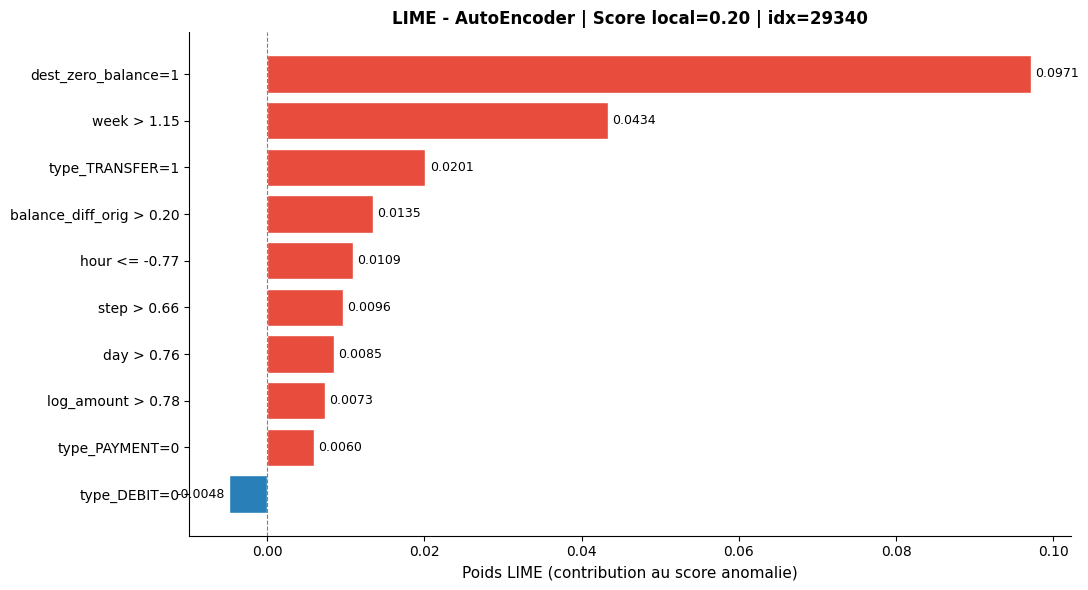

Figure 32 sauvegardee


In [29]:
lime_explainer_ae = LimeTabularExplainer(
    training_data         = X_train_arr,
    feature_names         = FEATURE_COLS,
    categorical_features  = cat_idx,
    mode                  = 'regression',
    random_state          = 42,
    discretize_continuous = True,
)

def ae_score_fn(X):
    return ae.predict_score(np.array(X, dtype=np.float32))

print('LIME AutoEncoder...', end=' ')
t0 = time.time()
exp_ae = lime_explainer_ae.explain_instance(
    data_row     = tx,
    predict_fn   = ae_score_fn,
    num_features = 10,
    num_samples  = 500,
)
print(f'OK ({time.time()-t0:.1f}s)')

# Extraction robuste local_pred pour regression
lp_ae = exp_ae.local_pred
local_pred_ae = float(lp_ae[-1]) if hasattr(lp_ae,'__len__') else float(lp_ae)

pairs_ae   = exp_ae.as_list()
rules_ae   = [p[0] for p in pairs_ae]
weights_ae = [p[1] for p in pairs_ae]

print(f'Prediction locale AE : {local_pred_ae:.4f}')

# Figure 32
df_lime_ae = pd.DataFrame({'rule': rules_ae, 'weight': weights_ae}).sort_values('weight', key=abs, ascending=False)
colors_ae  = [POS if w>0 else NEG for w in df_lime_ae['weight']]
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_lime_ae['rule'][::-1], df_lime_ae['weight'][::-1], color=colors_ae[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title(f'LIME - AutoEncoder | Score local={local_pred_ae:.2f} | idx={tx_idx}', fontsize=12, fontweight='bold')
ax.set_xlabel('Poids LIME (contribution au score anomalie)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '32_lime_ae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 32 sauvegardee')

## 11 — SHAP vs LIME côte-à-côte (Figure 34)

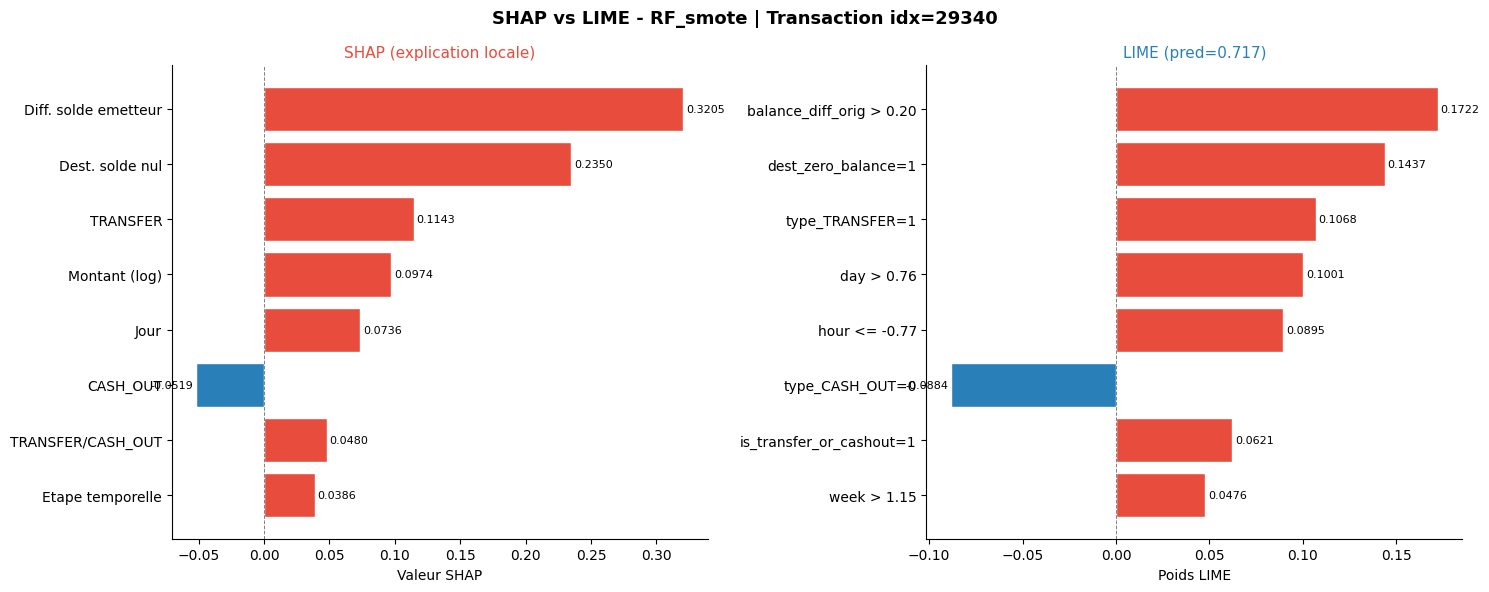

Figure 34 sauvegardee


In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'SHAP vs LIME - RF_smote | Transaction idx={tx_idx}', fontsize=13, fontweight='bold')

top8_s = shap_df.head(8)
cs = [POS if v>0 else NEG for v in top8_s['shap_value']]
b1 = ax1.barh(top8_s['feature_label'][::-1], top8_s['shap_value'][::-1], color=cs[::-1], edgecolor='white')
ax1.bar_label(b1, fmt='%.4f', fontsize=8, padding=2)
ax1.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax1.set_title('SHAP (explication locale)', fontsize=11, color=POS)
ax1.set_xlabel('Valeur SHAP')
ax1.spines[['top','right']].set_visible(False)

top8_l = df_lime_rf.head(8)
cl = [POS if w>0 else NEG for w in top8_l['weight']]
b2 = ax2.barh(top8_l['rule'][::-1], top8_l['weight'][::-1], color=cl[::-1], edgecolor='white')
ax2.bar_label(b2, fmt='%.4f', fontsize=8, padding=2)
ax2.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax2.set_title(f'LIME (pred={local_pred_rf:.3f})', fontsize=11, color=NEG)
ax2.set_xlabel('Poids LIME')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '34_shap_vs_lime.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 34 sauvegardee')

## 12 — Dashboard complet (Figure 35)

LLM status : fallback_no_llm | Risque : CRITIQUE



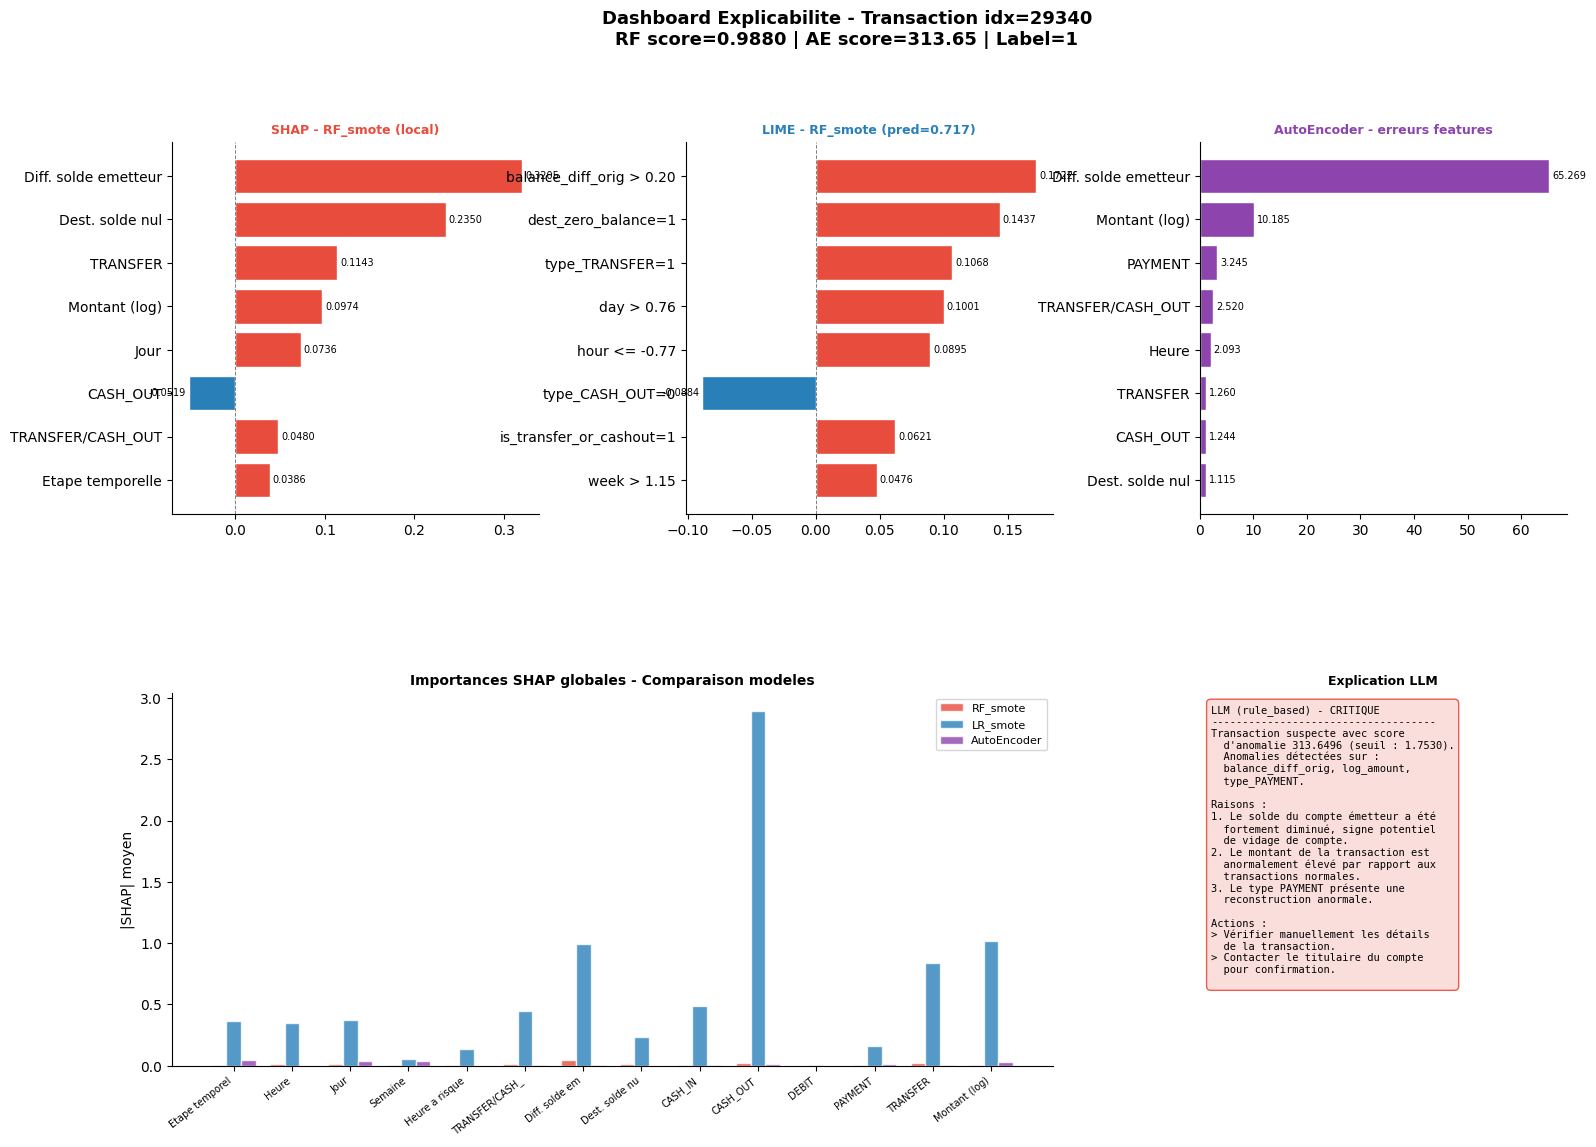

Figure 35 sauvegardee


In [32]:
import textwrap
import torch

# Erreurs de reconstruction AE par feature
ae.model.eval()
ae_device = next(ae.model.parameters()).device
tx_tensor = torch.from_numpy(tx.reshape(1, -1).astype(np.float32)).to(ae_device)
with torch.no_grad():
    tx_rec = ae.model(tx_tensor).cpu().numpy()[0]
feat_errs = np.abs(tx - tx_rec)

# LLM fallback (rule-based si Ollama absent)
from src.ollama_integration.ollama_helper import OllamaHelper
helper = OllamaHelper(model='mistral', timeout=90, feature_names=FEATURE_COLS)

tx_dict = dict(zip(FEATURE_COLS, tx.tolist()))
parsed  = helper.explain_fraud(
    transaction    = tx_dict,
    feature_errors = feat_errs,
    ae_score       = ae_score_tx,
    threshold      = ae.threshold,
)
print(f'LLM status : {parsed["status"]} | Risque : {parsed.get("risk_level","?")}\n')

# ── Figure 35 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f'Dashboard Explicabilite - Transaction idx={tx_idx}\n'
    f'RF score={rf_prob_tx:.4f} | AE score={ae_score_tx:.2f} | Label={true_label}',
    fontsize=13, fontweight='bold', y=0.99
)
gs = fig.add_gridspec(2, 3, hspace=0.48, wspace=0.40)

# Panel 1 : SHAP
ax1 = fig.add_subplot(gs[0,0])
top8s = shap_df.head(8)
cs1   = [POS if v>0 else NEG for v in top8s['shap_value']]
b = ax1.barh(top8s['feature_label'][::-1], top8s['shap_value'][::-1], color=cs1[::-1], edgecolor='white')
ax1.bar_label(b, fmt='%.4f', fontsize=7, padding=2)
ax1.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
ax1.set_title('SHAP - RF_smote (local)', fontweight='bold', fontsize=9, color=POS)
ax1.spines[['top','right']].set_visible(False)

# Panel 2 : LIME
ax2 = fig.add_subplot(gs[0,1])
top8l = df_lime_rf.head(8)
cl2   = [POS if w>0 else NEG for w in top8l['weight']]
b2 = ax2.barh(top8l['rule'][::-1], top8l['weight'][::-1], color=cl2[::-1], edgecolor='white')
ax2.bar_label(b2, fmt='%.4f', fontsize=7, padding=2)
ax2.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
ax2.set_title(f'LIME - RF_smote (pred={local_pred_rf:.3f})', fontweight='bold', fontsize=9, color=NEG)
ax2.spines[['top','right']].set_visible(False)

# Panel 3 : AE erreurs
ax3 = fig.add_subplot(gs[0,2])
top8e = np.argsort(feat_errs)[::-1][:8]
ae_lbls = [FEAT_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in top8e]
b3 = ax3.barh(ae_lbls[::-1], feat_errs[top8e][::-1], color=PURP, edgecolor='white')
ax3.bar_label(b3, fmt='%.3f', fontsize=7, padding=2)
ax3.set_title('AutoEncoder - erreurs features', fontweight='bold', fontsize=9, color=PURP)
ax3.spines[['top','right']].set_visible(False)

# Panel 4 : Comparaison globale SHAP
ax4 = fig.add_subplot(gs[1, 0:2])
x   = np.arange(len(FEATURE_COLS))
w   = 0.25
for mi, (mname, (_, col, mabs)) in enumerate(shap_dict.items()):
    ax4.bar(x + mi*w, mabs, w, label=mname, color=col, alpha=0.80, edgecolor='white')
ax4.set_xticks(x + w)
ax4.set_xticklabels([FEAT_LABELS.get(f,f)[:14] for f in FEATURE_COLS], rotation=38, ha='right', fontsize=7)
ax4.set_title('Importances SHAP globales - Comparaison modeles', fontweight='bold', fontsize=10)
ax4.set_ylabel('|SHAP| moyen')
ax4.legend(fontsize=8)
ax4.spines[['top','right']].set_visible(False)

# Panel 5 : Explication LLM
ax5 = fig.add_subplot(gs[1,2])
ax5.axis('off')
risk    = parsed.get('risk_level','?')
resume  = parsed.get('resume','')
raisons = parsed.get('raisons',[])
actions = parsed.get('actions_recommandees',[])
bg_col  = {'CRITIQUE':'#FADBD8','ELEVE':'#FDEBD0','MODERE':'#FEF9E7'}.get(risk,'#EBF5FB')
def w(t,n=38): return '\n  '.join(textwrap.wrap(str(t),n))
txt  = f'LLM ({parsed.get("model","?")}) - {risk}\n'
txt += '-'*36+'\n'
txt += w(resume)+'\n\nRaisons :\n'
for i,r in enumerate(raisons[:3],1): txt += f'{i}. {w(r,34)}\n'
txt += '\nActions :\n'
for a in actions[:2]: txt += f'> {w(a,34)}\n'
ax5.text(0.03, 0.97, txt, transform=ax5.transAxes, fontsize=7.5, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_col, alpha=0.9, edgecolor=POS if risk=='CRITIQUE' else '#AAA'))
ax5.set_title('Explication LLM', fontweight='bold', fontsize=9)

plt.savefig(FIGURES_DIR / '35_explainability_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 35 sauvegardee')

## 13 — Sauvegarde

In [33]:
# SHAP report
shap_report = {}
for mname, (vals, _, mabs) in shap_dict.items():
    order = np.argsort(mabs)[::-1]
    shap_report[mname] = [
        {'feature': FEATURE_COLS[i], 'mean_abs_shap': float(mabs[i])} for i in order
    ]

with open(REPORTS_DIR / 'shap_report.json', 'w', encoding='utf-8') as f:
    json.dump(shap_report, f, ensure_ascii=False, indent=2)
print('shap_report.json sauvegarde')

# LIME report
lime_report = {
    'transaction_idx'    : int(tx_idx),
    'ae_score'           : ae_score_tx,
    'rf_prob'            : rf_prob_tx,
    'true_label'         : true_label,
    'lime_rf_local_pred' : local_pred_rf,
    'lime_ae_local_pred' : local_pred_ae,
    'lime_rf_top_rules'  : rules_rf[:5],
    'lime_rf_weights'    : weights_rf[:5],
    'llm_explanation'    : parsed,
}
with open(REPORTS_DIR / 'lime_report.json', 'w', encoding='utf-8') as f:
    json.dump(lime_report, f, ensure_ascii=False, indent=2)
print('lime_report.json sauvegarde')

# SHAP numpy
for mname, (vals, _, _) in shap_dict.items():
    fname = f'shap_values_{mname.lower().replace("_","")}.npy'
    np.save(MODELS_DIR / fname, vals)
    print(f'{fname} ({vals.shape})')

print('\nFigures : 26, 27, 28, 29, 30, 31, 32, 33, 34, 35')

shap_report.json sauvegarde
lime_report.json sauvegarde
shap_values_rfsmote.npy ((500, 14))
shap_values_lrsmote.npy ((500, 14))
shap_values_autoencoder.npy ((200, 14))

Figures : 26, 27, 28, 29, 30, 31, 32, 33, 34, 35


## 14 — Synthèse

In [34]:
print('='*60)
print('  SYNTHESE - NB06 SHAP + LIME')
print('='*60)
for mname, (_, _, mabs) in shap_dict.items():
    top1 = FEATURE_COLS[np.argmax(mabs)]
    print(f'  SHAP {mname:<15s} -> feature #1 : {top1}')
print(f'\n  LIME RF_smote  : pred locale = {local_pred_rf:.4f}')
print(f'  LIME AE        : pred locale = {local_pred_ae:.4f}')
print(f'  LLM            : {parsed.get("status")} | Risque = {parsed.get("risk_level")}')
print('\n  Figures : 26 -> 35 | shap_report.json | lime_report.json')
print('='*60)

  SYNTHESE - NB06 SHAP + LIME
  SHAP RF_smote        -> feature #1 : balance_diff_orig
  SHAP LR_smote        -> feature #1 : type_CASH_OUT
  SHAP AutoEncoder     -> feature #1 : step

  LIME RF_smote  : pred locale = 0.7172
  LIME AE        : pred locale = 0.1962
  LLM            : fallback_no_llm | Risque = CRITIQUE

  Figures : 26 -> 35 | shap_report.json | lime_report.json
